# 02KcBERT_extract 노트북 목표
1. 정제된 리뷰 텍스트를 KcBERT를 통해 임베딩 벡터를 추출한다.

## 1. 라이브러리 로드
- 전처리된 리뷰 데이터를 불러오고, KcBERT 임베딩을 추출하기 위한 패키지를 불러온다.
- 각 패키지의 역할은 다음과 같다.
  1. `pathlib`: 기존 임베딩 파일이 있는지 확인한다.
  2. `pandas`: CSV 데이터를 불러오고 최종 데이터프레임을 만든다.
  3. `numpy`: 배치별 임베딩 배열을 하나로 합친다.
  4. `matplotlib`: label 분포와 리뷰 길이 분포를 시각화한다.
  5. `torch`: GPU/CPU 환경에서 KcBERT 모델을 실행한다.
  6. `transformers`: Hugging Face의 KcBERT 모델과 토크나이저를 불러온다.
  7. `tqdm`: 임베딩 추출 진행률을 표시한다.

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

## 2. 실행 설정 및 GPU/CPU 환경 확인

- 입력 파일과 출력 파일 경로를 설정한다.
- 기존 임베딩 CSV가 있으면 재사용하고, 없을 때만 KcBERT 임베딩을 새로 생성한다.
- GPU가 사용 가능하면 `cuda`, 그렇지 않으면 `cpu`를 사용한다.


In [18]:
PREPROCESSED_PATH = 'csv/preprocessed_reviews.csv'
EMBEDDING_PATH = 'csv/reviews_embeddings_extract.csv'
embedding_file = Path(EMBEDDING_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 환경: {device}")


현재 사용 중인 환경: cuda


## 3. 전처리된 데이터 로드

- 이전 단계(`01data-process.ipynb`)에서 정제한 리뷰 데이터(`preprocessed_reviews.csv`)를 불러온다.
- 전체 데이터 개수 및 리뷰 이벤트(label) 분포를 확인한다.
- 텍스트 길이와 레이블 분포를 시각화하여 데이터의 전반적인 특성을 파악한다.


전처리 데이터 로드: (8841, 14)
전체 데이터 개수: 8841
label
0    5691
1    3150
Name: count, dtype: int64


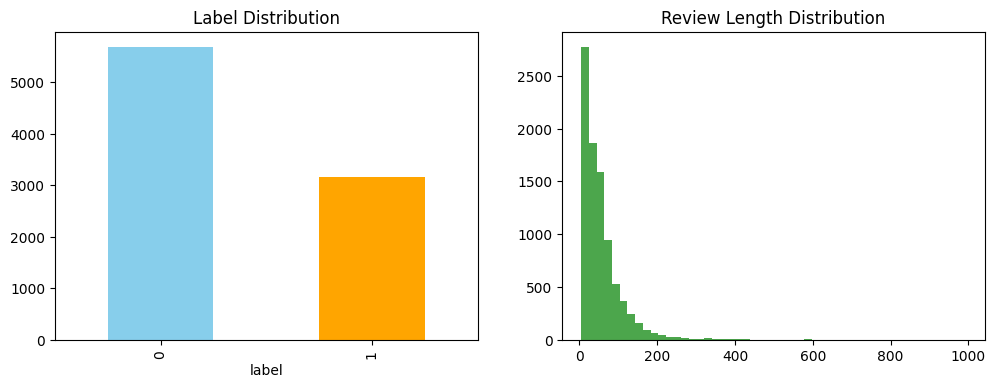

In [19]:
df = pd.read_csv(PREPROCESSED_PATH)
print(f"전처리 데이터 로드: {df.shape}")

print(f"전체 데이터 개수: {len(df)}")
print(df['label'].value_counts())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axs[0], color=['skyblue', 'orange'])
axs[0].set_title('Label Distribution')

# 리뷰 길이 분포 확인
axs[1].hist(df['text_length'], bins=50, color='green', alpha=0.7)
axs[1].set_title('Review Length Distribution')

plt.show()


## 4. KcBERT 모델 및 토크나이저 로드

- `beomi/kcbert-base` 사전 학습 모델과 토크나이저를 불러온다.
- 추가 학습(Fine-tuning)이 아닌 특징 추출(Feature Extraction)이 목적이므로 모델을 평가 모드(`model.eval()`)로 전환하여 가중치를 고정한다.


In [20]:
# 특징 추출기로 활용하기 위해 가중치를 고정
model_name = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# 모델을 평가 모드로 전환 (특징 추출 모드)
model.eval()
print(f"{model_name} 로드 완료")


beomi/kcbert-base 로드 완료


## 5. KcBERT 입력 텍스트 확인

- 전처리 과정에서 생성한 `cleaned_review_text`를 KcBERT 입력으로 사용한다.
- 결측값은 빈 문자열로 채워 모델 입력 오류를 방지한다.


In [21]:
input_series = df["cleaned_review_text"].fillna("").astype(str)
reviews = input_series.tolist()

print("전처리된 CSV 형태:", df.shape)
print("KcBERT 입력 컬럼 형태:", input_series.shape)
print("KcBERT 입력 컬럼명: cleaned_review_text")
print(input_series.head(3))


전처리된 CSV 형태: (8841, 14)
KcBERT 입력 컬럼 형태: (8841,)
KcBERT 입력 컬럼명: cleaned_review_text
0                 좋아하는집인데 배달은 안하시는게... 떡국이아니라 떡죽이네요...
1                                     ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ
2    이걸 수습하기가 참.. 귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러서...
Name: cleaned_review_text, dtype: object


## 6. 배치 단위 임베딩 벡터 추출

- 기존 임베딩 CSV가 있으면 해당 파일을 읽고, 없으면 새로 추출한다.
    - 다만 01번 전처리 결과가 바뀐 경우, 기존 임베딩 파일을 삭제한 뒤 02번을 다시 실행해야 한다.
- 메모리 부족(OOM) 방지를 위해 데이터를 지정된 배치 사이즈(batch_size)로 나누어 처리한다.
- `torch.no_grad()`를 통해 그래디언트 계산을 비활성화하여 추론 속도를 높인다.
- 문맥을 대표하는 `[CLS]` 토큰의 벡터(768차원)만 추출하여 리스트에 누적한 뒤, 최종적으로 병합(`np.vstack`)한다.


In [22]:
if embedding_file.exists():
    df_final = pd.read_csv(EMBEDDING_PATH)
    emb_columns = [col for col in df_final.columns if col.startswith('kcbert_')]
    final_embeddings = df_final[emb_columns].to_numpy()
    print("기존 임베딩 파일 사용:", final_embeddings.shape)
else:
    batch_size = 32
    cls_embeddings = []

    model.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(reviews), batch_size)):
            batch_text = reviews[i : i + batch_size]

            inputs = tokenizer(
                batch_text,
                return_tensors="pt",
                truncation=True,
                max_length=128,
                padding="max_length"
            ).to(device)

            outputs = model(**inputs)

            # [CLS] 토큰 벡터 추출
            cls_vector = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            cls_embeddings.append(cls_vector)

    # 배치별 결과를 하나로 합치기
    final_embeddings = np.vstack(cls_embeddings)
    print("임베딩 추출 완료:", final_embeddings.shape)


기존 임베딩 파일 사용: (8841, 768)


C:\Users\ICT\AppData\Local\Temp\ipykernel_21680\2954462317.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv(EMBEDDING_PATH)


In [23]:
# 출력
print("전처리된 CSV 형태:", df.shape)
print("KcBERT 입력 리뷰 개수:", len(reviews))
print("KcBERT 입력 샘플 3개:")
for i, text in enumerate(reviews[:3]):
    print(f"{i}: {text}")

전처리된 CSV 형태: (8841, 14)
KcBERT 입력 리뷰 개수: 8841
KcBERT 입력 샘플 3개:
0: 좋아하는집인데 배달은 안하시는게... 떡국이아니라 떡죽이네요...
1: ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ
2: 이걸 수습하기가 참.. 귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러서모든 용기마다 닦아가며 정리하려니. 손대기도 싫고 입맛이 사라지네요 아..짜..


## 7. 벡터 데이터 병합 및 최종 데이터 산출

- 기존 임베딩 CSV가 있으면 해당 파일을 유지한다.
- 새로 추출한 경우에는 768차원의 넘파이 배열을 `kcbert_0` ~ `kcbert_767` 형태의 개별 컬럼을 가진 데이터프레임으로 변환한다.
- 원본 분석 컬럼과 임베딩 벡터를 병합(`pd.concat`)한다.
- 최종 산출물을 `reviews_embeddings_extract.csv`로 저장한다.


In [24]:
if embedding_file.exists():
    print(f"기존 산출물 유지: {EMBEDDING_PATH}")
else:
    # 768차원 배열을 각각의 컬럼으로 변환
    emb_columns = [f'kcbert_{i}' for i in range(final_embeddings.shape[1])]
    df_embeddings = pd.DataFrame(final_embeddings, columns=emb_columns)

    # 기존 메타데이터와 결합
    df_final = pd.concat([df.reset_index(drop=True), df_embeddings], axis=1)

    # CSV 저장 (인덱스 제외)
    df_final.to_csv(EMBEDDING_PATH, index=False, encoding='utf-8-sig')
    print(f"최종 산출물 저장 완료: {EMBEDDING_PATH}")

original_csv_col_count = df.shape[1]
embedding_col_count = len(emb_columns)
expected_final_col_count = original_csv_col_count + embedding_col_count
final_col_count = df_final.shape[1]
row_count_match = (
    df.shape[0]
    == input_series.shape[0]
    == final_embeddings.shape[0]
    == df_final.shape[0]
)
column_count_match = expected_final_col_count == final_col_count

print("전처리된 CSV 형태:", df.shape)
print("KcBERT 입력 컬럼 형태:", input_series.shape)
print("KcBERT 추출 임베딩 형태:", final_embeddings.shape)
print("최종 임베딩 CSV 형태:", df_final.shape)
print("기존 CSV 컬럼 수:", original_csv_col_count)
print("KcBERT 임베딩 컬럼 수:", embedding_col_count)
print(f"최종 컬럼 수: {original_csv_col_count} + {embedding_col_count} = {final_col_count}")

df_final.head(3)


기존 산출물 유지: csv/reviews_embeddings_extract.csv
전처리된 CSV 형태: (8841, 14)
KcBERT 입력 컬럼 형태: (8841,)
KcBERT 추출 임베딩 형태: (8841, 768)
최종 임베딩 CSV 형태: (8841, 782)
기존 CSV 컬럼 수: 14
KcBERT 임베딩 컬럼 수: 768
최종 컬럼 수: 14 + 768 = 782


,store_url,store_name,rating,review_text,menu_name,image_urls,source_file,review_text_raw,menu_name_raw,label,...,kcbert_758,kcbert_759,kcbert_760,kcbert_761,kcbert_762,kcbert_763,kcbert_764,kcbert_765,kcbert_766,kcbert_767
0,https://s.baemin.com/pG000flG524ai,NaN,1.0,좋아하는집인데 배달은 안하시는게...\n떡국이아니라 떡죽이네요...,[1인세트메뉴] 국수/국밥+만두/맛보기수육,"[""https://bmreview.cdn.baemin.com/bmreview-qh2...",배달의민족_리뷰_수집_부산.xlsx,좋아하는집인데 배달은 안하시는게...\n떡국이아니라 떡죽이네요...,[1인세트메뉴] 국수/국밥+만두/맛보기수육,0,...,0.157947,0.867351,0.697372,-0.177131,-1.542130,-1.082312,0.580298,1.350956,0.932172,0.049817
1,https://s.baemin.com/pG000flG524ai,NaN,1.0,ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ,[1인세트메뉴] 국수/국밥+만두/맛보기수육,NaN,배달의민족_리뷰_수집_부산.xlsx,ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ,[1인세트메뉴] 국수/국밥+만두/맛보기수육,0,...,0.540310,0.130053,0.812165,-0.633799,-0.177508,0.179927,2.077485,-0.652073,0.006927,0.943704
2,https://s.baemin.com/pG000flG524ai,NaN,1.0,이걸 수습하기가 참..\n귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러...,"멸치국수,비빔국수,비빔밥","[""https://bmreview.cdn.baemin.com/bmreview-qh2...",배달의민족_리뷰_수집_부산.xlsx,이걸 수습하기가 참..\n귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러...,"멸치국수,비빔국수,비빔밥",0,...,-0.091087,0.480046,1.910374,-0.242731,-2.281243,-0.339325,0.666222,0.218764,1.738482,0.712517
